<a href="https://colab.research.google.com/github/kxrrym03/Sleep-Doomscrolling-Habits/blob/main/Sleep_%26_Doomscrolling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sleep_doomscrolling_habits.csv to sleep_doomscrolling_habits.csv


In [ ]:
df = pd.read_csv('sleep_doomscrolling_habits.csv')
df.shape

(1000, 30)

In [ ]:
df.head()

,respondent_id,age,bedtime_screen_time_minutes,total_daily_screen_time_hours,doomscroll_sessions_per_night,avg_doomscroll_session_minutes,sleep_hours_per_night,sleep_latency_minutes,number_of_night_wakeups,caffeine_intake_mg_per_day,...,occupation_status,country_region,primary_device_used_at_night,bedtime_routine_type,uses_night_mode,keeps_phone_in_bedroom,consumes_negative_news_content,uses_sleep_tracking_app,doomscroller,sleep_quality_category
0,D30000,22,13.0,1.85,2,5.4,8.1,19.0,2,155.0,...,Unemployed,Germany,Tablet,Meditation/Journaling,Yes,Yes,Yes,No,Yes,Good
1,D30001,18,90.0,3.61,3,29.6,7.0,31.0,3,82.0,...,Student,India,Smartphone,Meditation/Journaling,No,Yes,Yes,No,Yes,Poor
2,D30002,37,51.0,5.15,3,15.5,7.1,24.0,2,49.0,...,Student,India,Laptop,Reading,No,Yes,No,Yes,Yes,Fair
3,D30003,27,53.0,3.74,0,51.4,8.4,35.0,0,42.0,...,NaN,United States,Smartphone,No Fixed Routine,No,Yes,Yes,No,No,Fair
4,D30004,17,67.0,6.09,2,32.2,7.2,19.0,1,76.0,...,Employed Part-time,United States,Smartphone,Watching Videos,No,No,No,No,No,Fair


In [ ]:
df.tail()

,respondent_id,age,bedtime_screen_time_minutes,total_daily_screen_time_hours,doomscroll_sessions_per_night,avg_doomscroll_session_minutes,sleep_hours_per_night,sleep_latency_minutes,number_of_night_wakeups,caffeine_intake_mg_per_day,...,occupation_status,country_region,primary_device_used_at_night,bedtime_routine_type,uses_night_mode,keeps_phone_in_bedroom,consumes_negative_news_content,uses_sleep_tracking_app,doomscroller,sleep_quality_category
995,D30995,26,85.0,3.56,4,25.4,7.6,34.0,1,169.0,...,Student,India,Tablet,Meditation/Journaling,No,Yes,Yes,Yes,Yes,Poor
996,D30996,23,3.0,1.10,1,10.7,7.5,31.0,1,34.0,...,Student,United States,Smartphone,Scrolling Social Media,No,Yes,No,No,No,Fair
997,D30997,15,28.0,4.38,1,30.6,9.2,20.0,0,100.0,...,Employed Full-time,United States,Smartphone,Scrolling Social Media,No,Yes,No,No,No,Good
998,D30998,22,23.0,1.84,0,27.9,6.9,41.0,2,45.0,...,Student,India,Tablet,Watching Videos,No,Yes,Yes,Yes,No,Fair
999,D30999,23,35.0,1.66,2,16.2,7.5,27.0,2,63.0,...,Employed Full-time,India,Tablet,Scrolling Social Media,No,Yes,Yes,No,Yes,Fair


In [ ]:
df.columns

Index(['respondent_id', 'age', 'bedtime_screen_time_minutes',
       'total_daily_screen_time_hours', 'doomscroll_sessions_per_night',
       'avg_doomscroll_session_minutes', 'sleep_hours_per_night',
       'sleep_latency_minutes', 'number_of_night_wakeups',
       'caffeine_intake_mg_per_day', 'anxiety_score', 'stress_score',
       'sleep_quality_score', 'daytime_fatigue_score',
       'number_of_news_apps_used', 'phone_checks_per_night',
       'exercise_minutes_per_day', 'days_since_last_digital_detox',
       'weekly_sleep_debt_hours', 'gender', 'occupation_status',
       'country_region', 'primary_device_used_at_night',
       'bedtime_routine_type', 'uses_night_mode', 'keeps_phone_in_bedroom',
       'consumes_negative_news_content', 'uses_sleep_tracking_app',
       'doomscroller', 'sleep_quality_category'],
      dtype='object')

In [ ]:
df.dtypes

,0
respondent_id,object
age,int64
bedtime_screen_time_minutes,float64
total_daily_screen_time_hours,float64
doomscroll_sessions_per_night,int64
avg_doomscroll_session_minutes,float64
sleep_hours_per_night,float64
sleep_latency_minutes,float64
number_of_night_wakeups,int64
caffeine_intake_mg_per_day,float64


In [ ]:
df.isnull().sum()

,0
respondent_id,0
age,0
bedtime_screen_time_minutes,0
total_daily_screen_time_hours,0
doomscroll_sessions_per_night,0
avg_doomscroll_session_minutes,0
sleep_hours_per_night,0
sleep_latency_minutes,0
number_of_night_wakeups,0
caffeine_intake_mg_per_day,50


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Impute numerical columns with the median
numerical_cols_with_nulls = [
    'caffeine_intake_mg_per_day',
    'sleep_quality_score',
    'exercise_minutes_per_day'
]

for col in numerical_cols_with_nulls:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"Missing values in '{col}' imputed with median: {median_val}")

Missing values in 'caffeine_intake_mg_per_day' imputed with median: 102.0
Missing values in 'sleep_quality_score' imputed with median: 5.0
Missing values in 'exercise_minutes_per_day' imputed with median: 54.0


In [ ]:
# Impute categorical columns with the mode
categorical_cols_with_nulls = [
    'occupation_status',
    'primary_device_used_at_night',
    'bedtime_routine_type'
]

for col in categorical_cols_with_nulls:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f"Missing values in '{col}' imputed with mode: {mode_val}")

Missing values in 'occupation_status' imputed with mode: Employed Full-time
Missing values in 'primary_device_used_at_night' imputed with mode: Smartphone
Missing values in 'bedtime_routine_type' imputed with mode: Scrolling Social Media


In [ ]:
# Verify that all null values have been handled
display(df.isnull().sum())

,0
respondent_id,0
age,0
bedtime_screen_time_minutes,0
total_daily_screen_time_hours,0
doomscroll_sessions_per_night,0
avg_doomscroll_session_minutes,0
sleep_hours_per_night,0
sleep_latency_minutes,0
number_of_night_wakeups,0
caffeine_intake_mg_per_day,0


## Data Visualization

### Distribution of Numerical Features

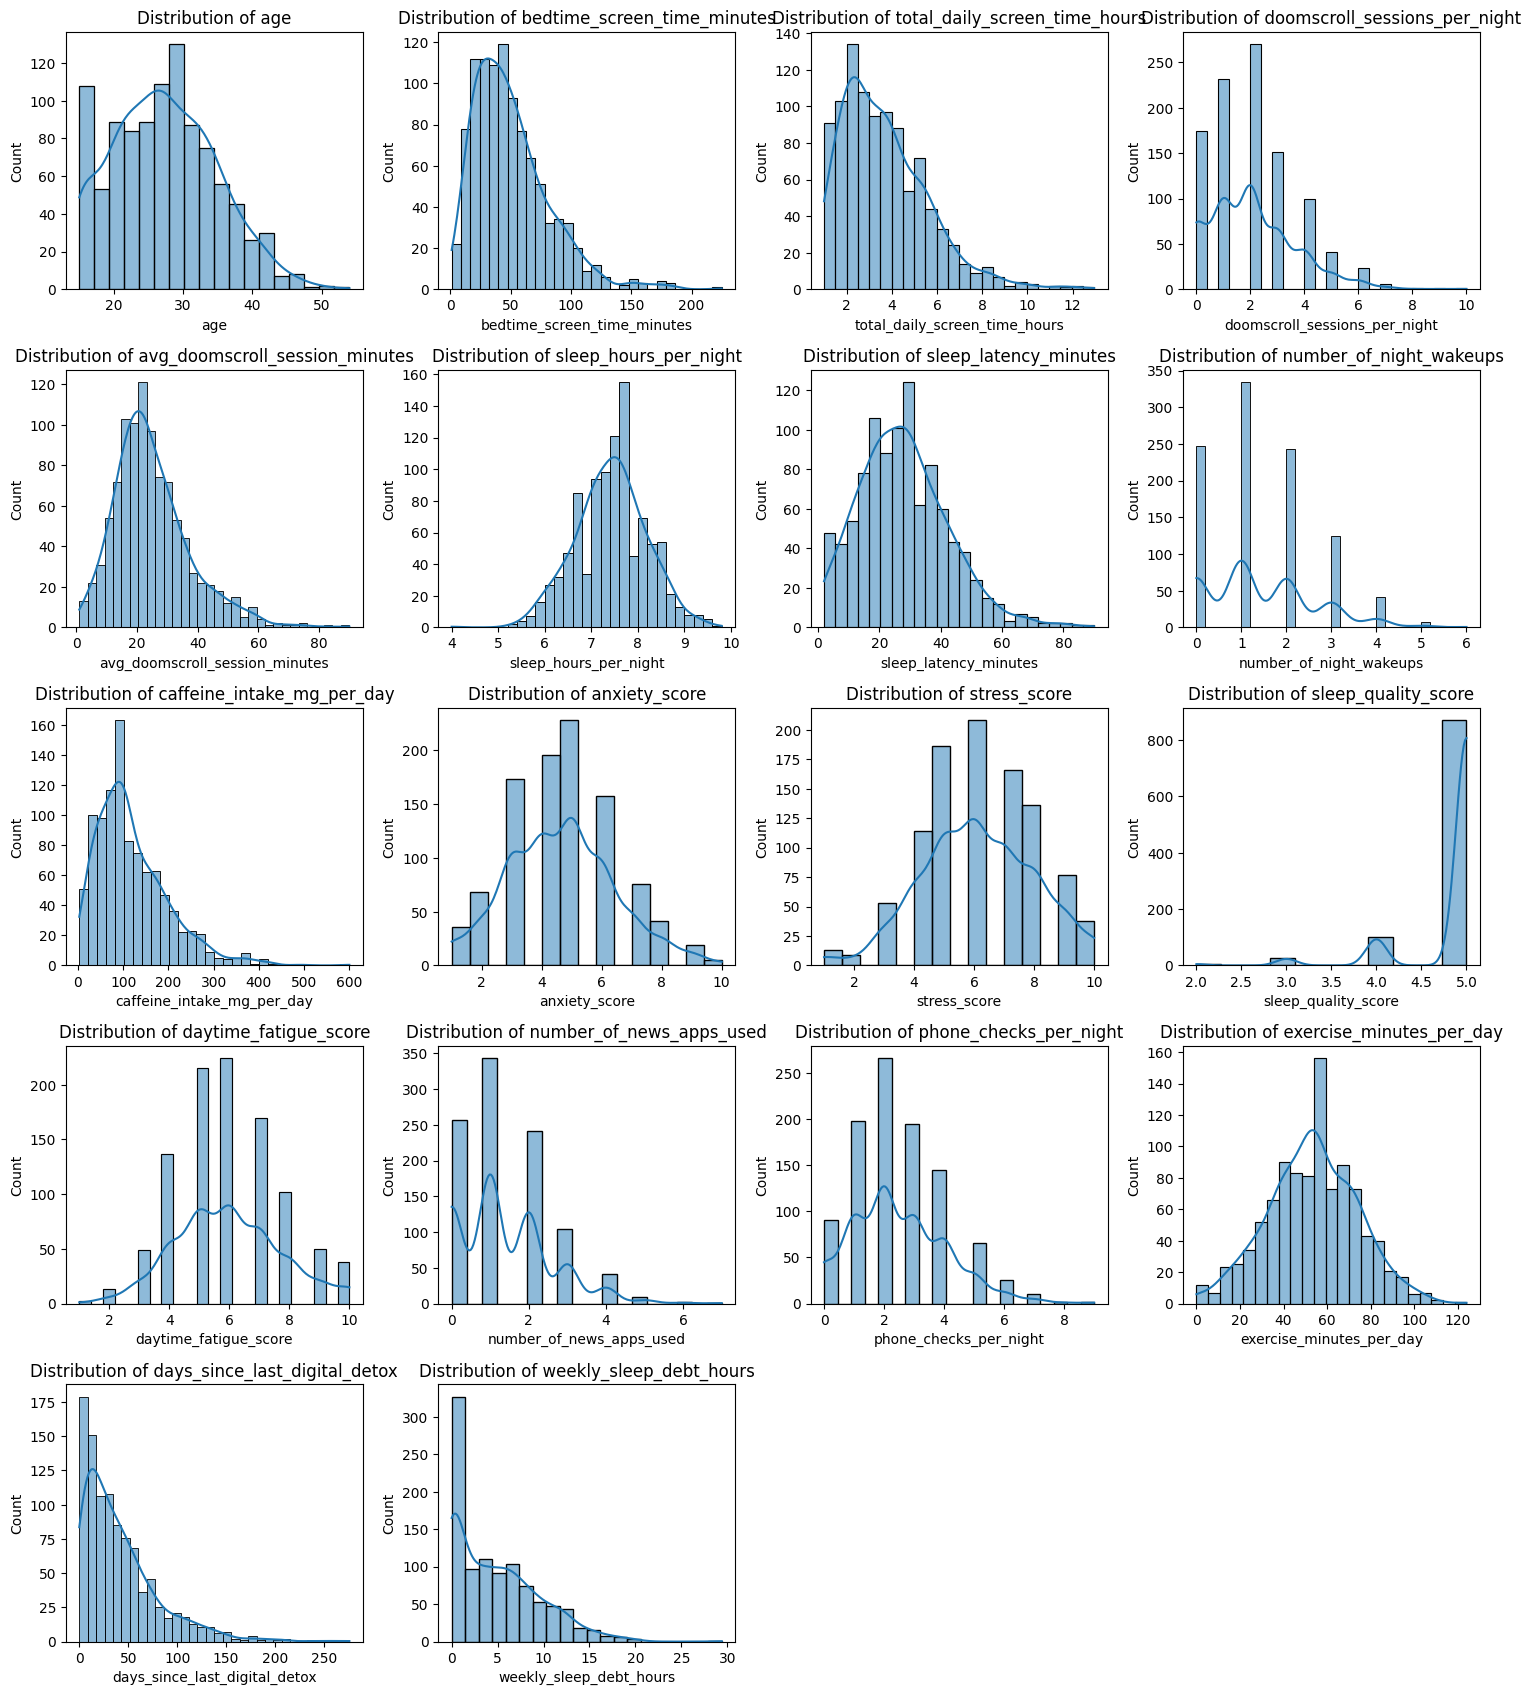

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 20))
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 4, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

### Distribution of Categorical Features

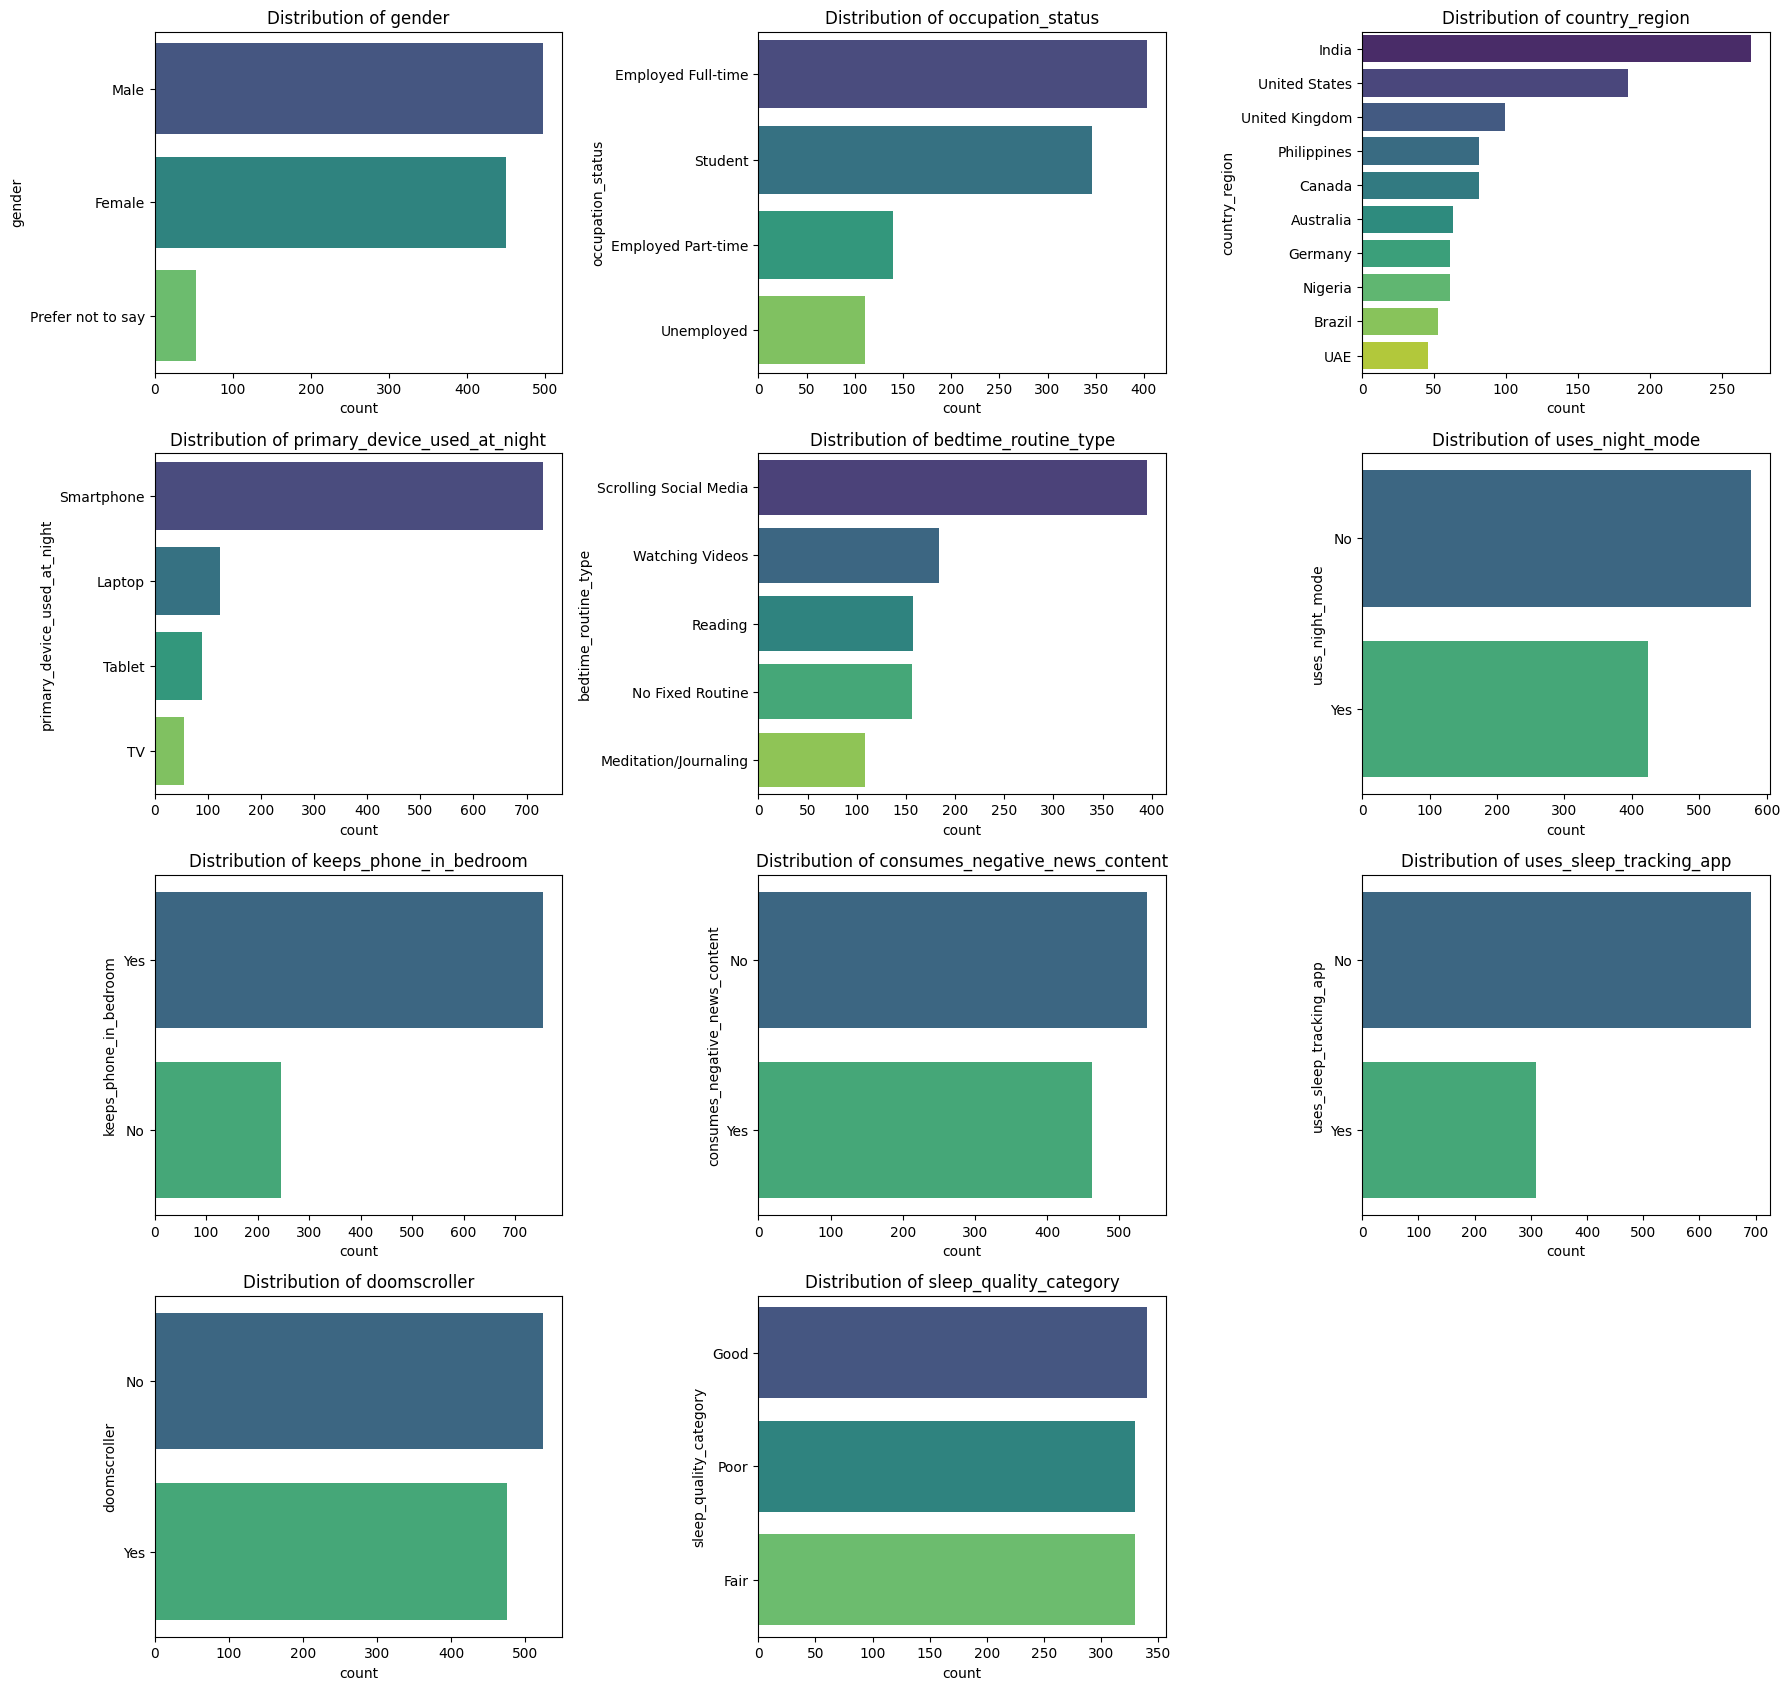

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

categorical_cols.remove('respondent_id')

plt.figure(figsize=(18, 25))
for i, col in enumerate(categorical_cols):
    plt.subplot(6, 3, i + 1)
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

### Relationship between Doomscrolling and Sleep Quality

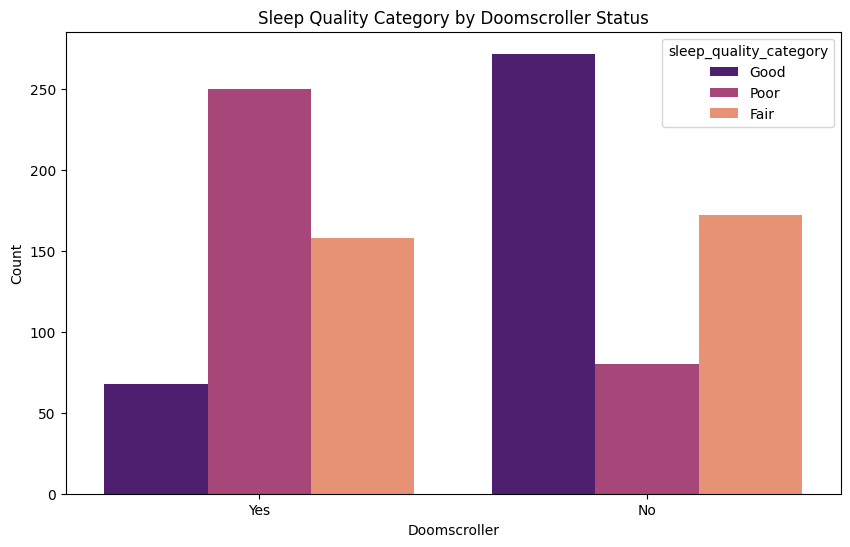

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='doomscroller', hue='sleep_quality_category', palette='magma')
plt.title('Sleep Quality Category by Doomscroller Status')
plt.xlabel('Doomscroller')
plt.ylabel('Count')
plt.show()

### Correlation between Bedtime Screen Time and Sleep Quality

In [ ]:
correlation = df['bedtime_screen_time_minutes'].corr(df['sleep_quality_score'])
print(f"Correlation between bedtime screen time and sleep quality: {correlation:.2f}")

Correlation between bedtime screen time and sleep quality: -0.42


### Scatter Plot: Bedtime Screen Time vs. Sleep Quality

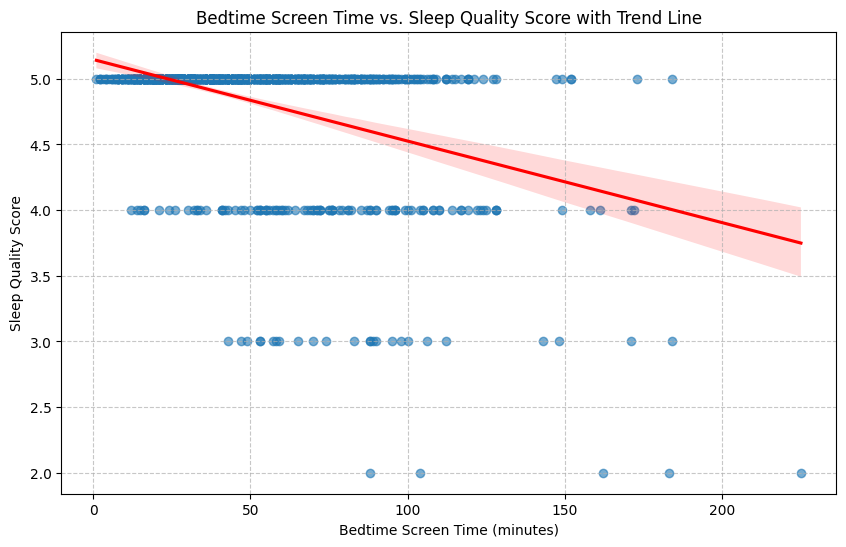

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='bedtime_screen_time_minutes', y='sleep_quality_score',
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Bedtime Screen Time vs. Sleep Quality Score with Trend Line')
plt.xlabel('Bedtime Screen Time (minutes)')
plt.ylabel('Sleep Quality Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Average Sleep Quality Score for Doomscrollers vs. Non-Doomscrollers

In [ ]:
average_sleep_quality = df.groupby('doomscroller')['sleep_quality_score'].mean().reset_index()
print("Average Sleep Quality Score by Doomscroller Status:")
print(average_sleep_quality)

Average Sleep Quality Score by Doomscroller Status:
  doomscroller  sleep_quality_score
0           No             4.912214
1          Yes             4.750000


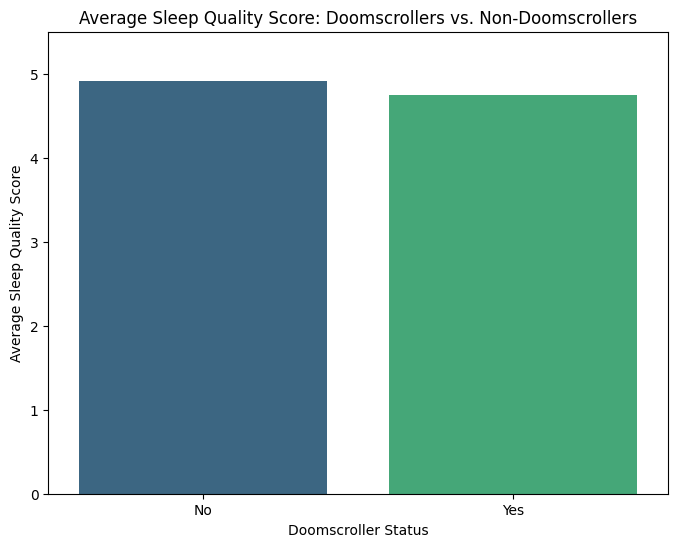

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(data=average_sleep_quality, x='doomscroller', y='sleep_quality_score', palette='viridis')
plt.title('Average Sleep Quality Score: Doomscrollers vs. Non-Doomscrollers')
plt.xlabel('Doomscroller Status')
plt.ylabel('Average Sleep Quality Score')
plt.ylim(0, df['sleep_quality_score'].max() * 1.1)
plt.show()

### Boxplot of Sleep Quality Scores by Category

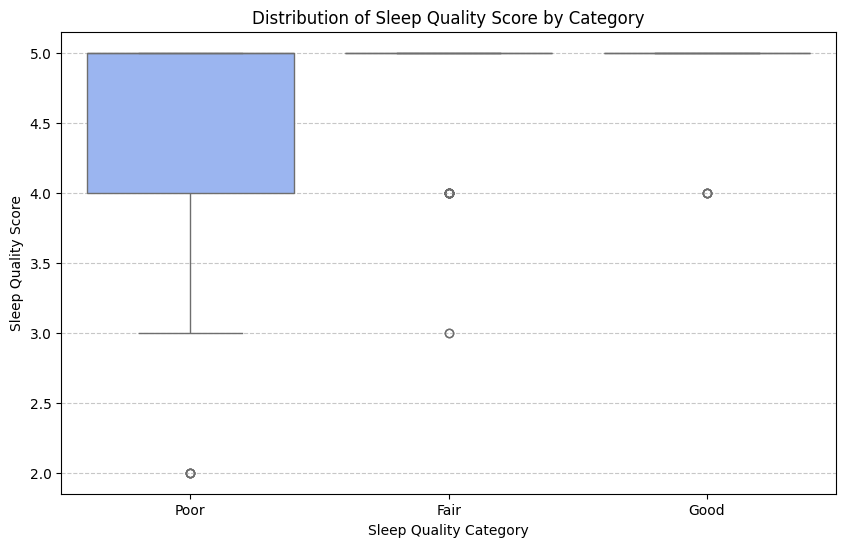

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sleep_quality_category', y='sleep_quality_score', palette='coolwarm', order=['Poor', 'Fair', 'Good'])
plt.title('Distribution of Sleep Quality Score by Category')
plt.xlabel('Sleep Quality Category')
plt.ylabel('Sleep Quality Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Statistical Test: Comparing Sleep Quality Across Doomscroller Statuses

In [ ]:
from scipy import stats

# Separate sleep quality scores for doomscrollers and non-doomscrollers
sleep_quality_doomscrollers = df[df['doomscroller'] == 'Yes']['sleep_quality_score']
sleep_quality_non_doomscrollers = df[df['doomscroller'] == 'No']['sleep_quality_score']

# Perform independent samples t-test
t_stat, p_value = stats.ttest_ind(sleep_quality_doomscrollers, sleep_quality_non_doomscrollers)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Conclusion: There is a statistically significant difference in sleep quality scores between doomscrollers and non-doomscrollers (reject null hypothesis).")
else:
    print("Conclusion: There is no statistically significant difference in sleep quality scores between doomscrollers and non-doomscrollers (fail to reject null hypothesis).")

T-statistic: -5.57
P-value: 0.000
Conclusion: There is a statistically significant difference in sleep quality scores between doomscrollers and non-doomscrollers (reject null hypothesis).


### Calculate Effect Size (Cohen's d)

In [ ]:
import numpy as np

# Calculate means and standard deviations for both groups
mean_doomscrollers = sleep_quality_doomscrollers.mean()
std_doomscrollers = sleep_quality_doomscrollers.std()
n_doomscrollers = len(sleep_quality_doomscrollers)

mean_non_doomscrollers = sleep_quality_non_doomscrollers.mean()
std_non_doomscrollers = sleep_quality_non_doomscrollers.std()
n_non_doomscrollers = len(sleep_quality_non_doomscrollers)

# Calculate pooled standard deviation
pooled_std = np.sqrt(((n_doomscrollers - 1) * std_doomscrollers**2 + (n_non_doomscrollers - 1) * std_non_doomscrollers**2) / (n_doomscrollers + n_non_doomscrollers - 2))

# Calculate Cohen's d
cohens_d = (mean_doomscrollers - mean_non_doomscrollers) / pooled_std

print(f"Mean Sleep Quality (Doomscrollers): {mean_doomscrollers:.2f}")
print(f"Standard Deviation Sleep Quality (Doomscrollers): {std_doomscrollers:.2f}")
print(f"Mean Sleep Quality (Non-Doomscrollers): {mean_non_doomscrollers:.2f}")
print(f"Standard Deviation Sleep Quality (Non-Doomscrollers): {std_non_doomscrollers:.2f}")
print(f"Pooled Standard Deviation: {pooled_std:.2f}")
print(f"Cohen's d: {cohens_d:.2f}")

# Interpret Cohen's d
if abs(cohens_d) < 0.2:
    print("Effect size (Cohen's d) is negligible.")
elif abs(cohens_d) < 0.5:
    print("Effect size (Cohen's d) is small.")
elif abs(cohens_d) < 0.8:
    print("Effect size (Cohen's d) is medium.")
else:
    print("Effect size (Cohen's d) is large.")

Mean Sleep Quality (Doomscrollers): 4.75
Standard Deviation Sleep Quality (Doomscrollers): 0.58
Mean Sleep Quality (Non-Doomscrollers): 4.91
Standard Deviation Sleep Quality (Non-Doomscrollers): 0.32
Pooled Standard Deviation: 0.46
Cohen's d: -0.35
Effect size (Cohen's d) is small.


### Correlation Heatmap of Numerical Variables

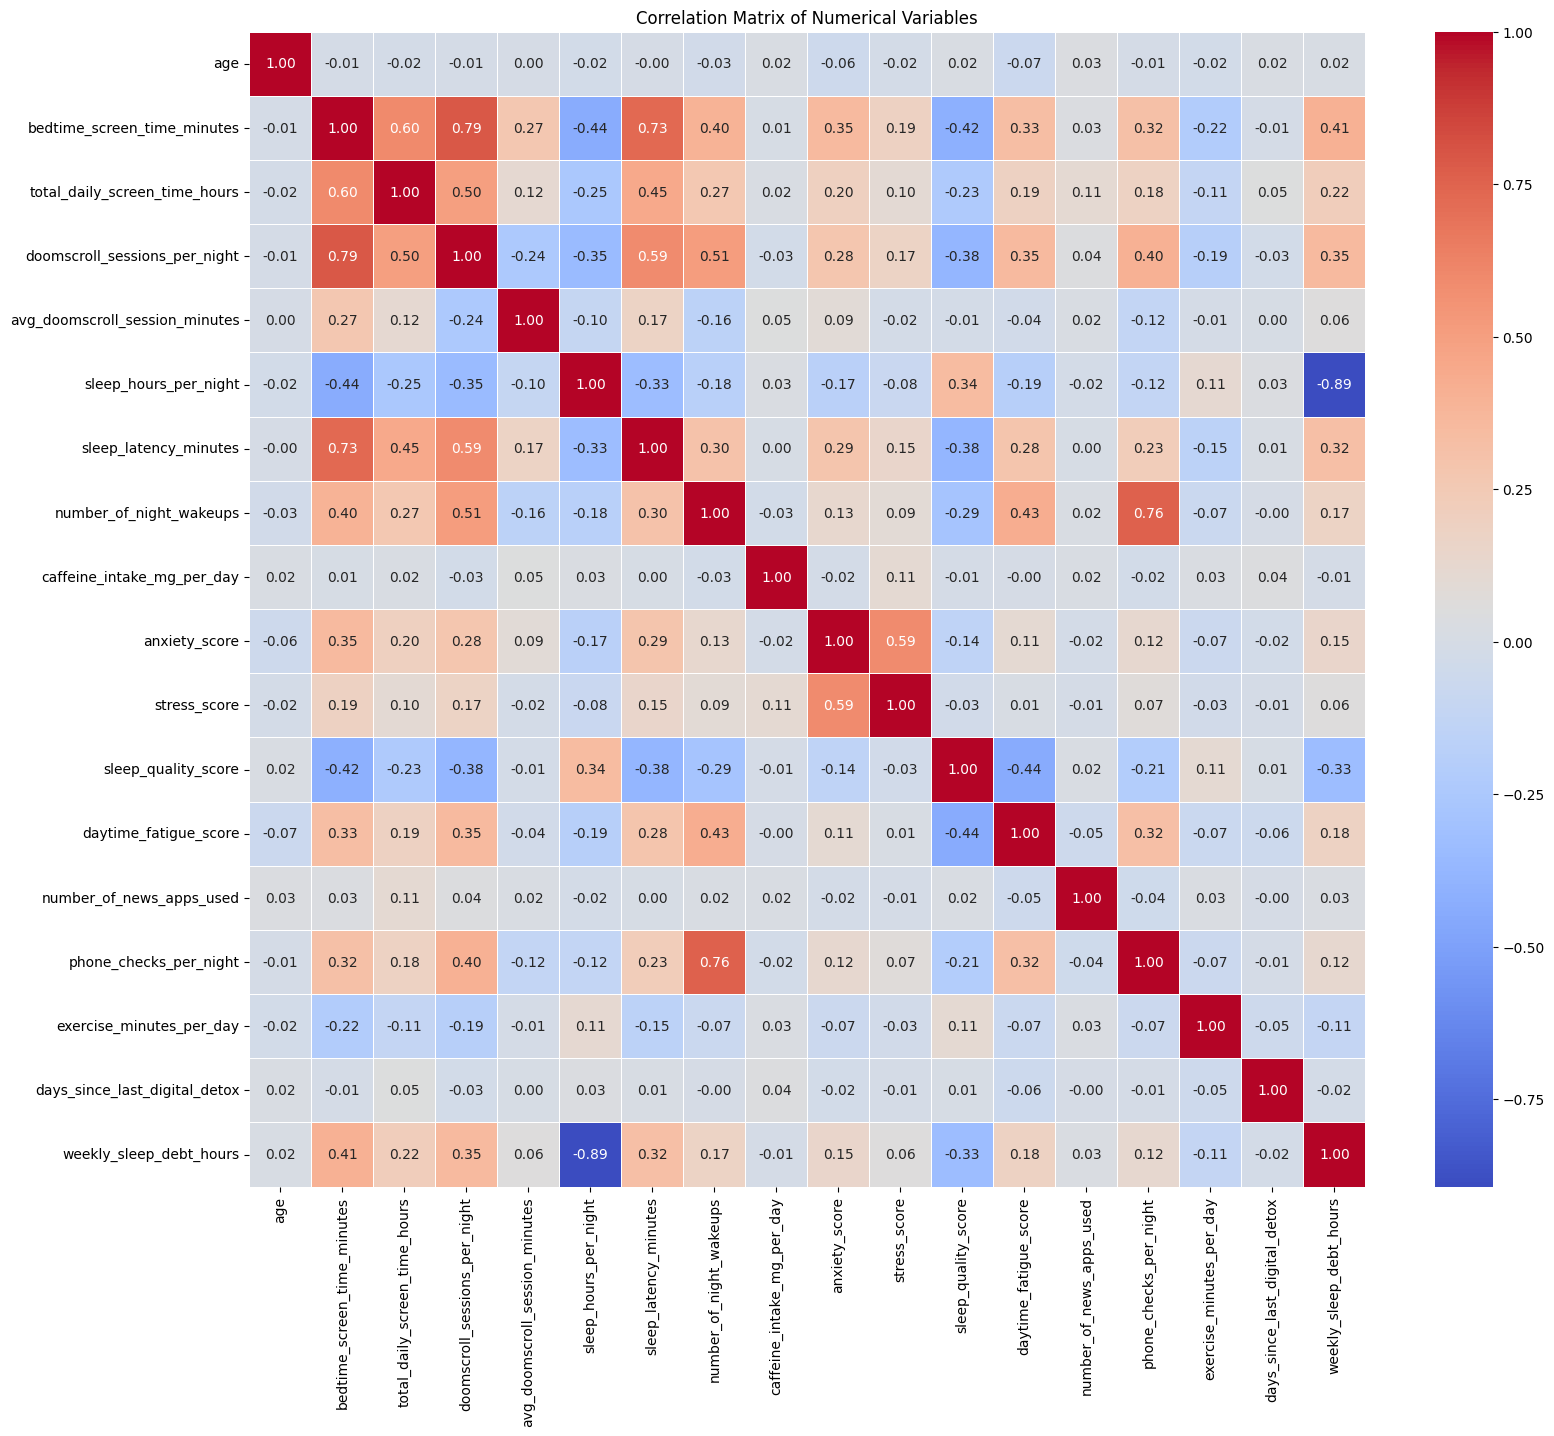

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

## Machine Learning: Predicting Sleep Quality

### Feature Engineering and Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define target and features
X = df.drop(['respondent_id', 'sleep_quality_category'], axis=1)
y = df['sleep_quality_category']

# Identify categorical and numerical columns for preprocessing
categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(include=np.number).columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (800, 28)
Shape of X_test: (200, 28)
Shape of y_train: (800,)
Shape of y_test: (200,)


### Model Training: RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create a pipeline
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', RandomForestClassifier(random_state=42))])

# Train the model
model_pipeline.fit(X_train, y_train)

print("RandomForestClassifier trained successfully!")

RandomForestClassifier trained successfully!


### Model Evaluation

Accuracy: 0.60

Classification Report:
              precision    recall  f1-score   support

        Fair       0.49      0.39      0.44        66
        Good       0.60      0.69      0.64        68
        Poor       0.68      0.71      0.70        66

    accuracy                           0.60       200
   macro avg       0.59      0.60      0.59       200
weighted avg       0.59      0.60      0.59       200



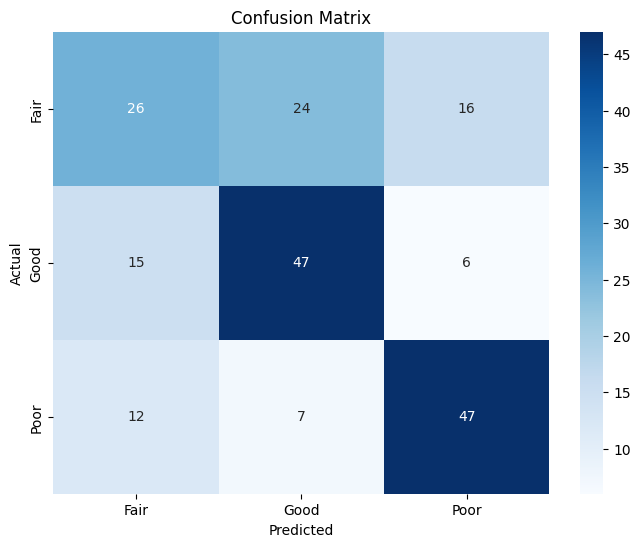

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model_pipeline.classes_,
            yticklabels=model_pipeline.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature Importance Analysis

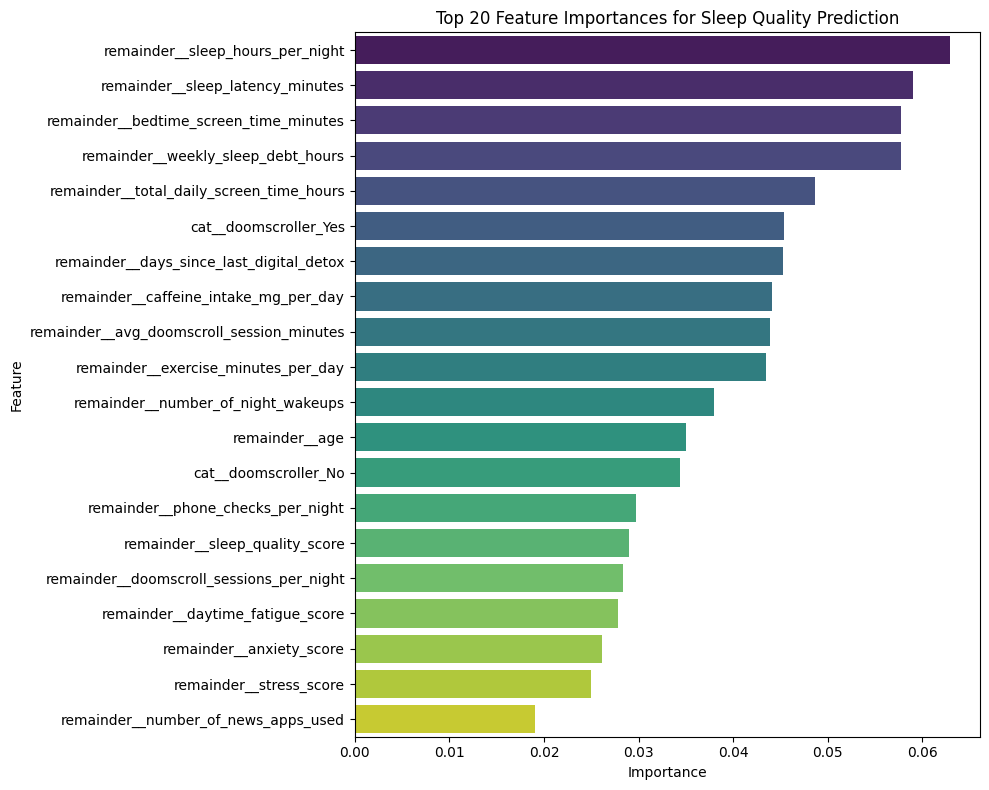

Top 20 Feature Importances:
                                      Feature  Importance
41           remainder__sleep_hours_per_night    0.062950
42           remainder__sleep_latency_minutes    0.059033
37     remainder__bedtime_screen_time_minutes    0.057759
53         remainder__weekly_sleep_debt_hours    0.057725
38   remainder__total_daily_screen_time_hours    0.048617
35                      cat__doomscroller_Yes    0.045325
52   remainder__days_since_last_digital_detox    0.045258
44      remainder__caffeine_intake_mg_per_day    0.044095
40  remainder__avg_doomscroll_session_minutes    0.043935
51        remainder__exercise_minutes_per_day    0.043520
43         remainder__number_of_night_wakeups    0.038016
36                             remainder__age    0.035006
34                       cat__doomscroller_No    0.034396
50          remainder__phone_checks_per_night    0.029760
47             remainder__sleep_quality_score    0.028945
39   remainder__doomscroll_sessions_per_nigh

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained RandomForestClassifier
feature_importances = model_pipeline.named_steps['classifier'].feature_importances_

feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the top 20 most important features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances for Sleep Quality Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Top 20 Feature Importances:")
print(importance_df.head(20))

### Model Training: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create a pipeline with Logistic Regression
logistic_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('classifier', LogisticRegression(random_state=42, solver='liblinear'))])

# Train the model
logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Model Evaluation: Logistic Regression

Accuracy (Logistic Regression): 0.61

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

        Fair       0.49      0.38      0.43        66
        Good       0.61      0.69      0.65        68
        Poor       0.69      0.76      0.72        66

    accuracy                           0.61       200
   macro avg       0.60      0.61      0.60       200
weighted avg       0.60      0.61      0.60       200



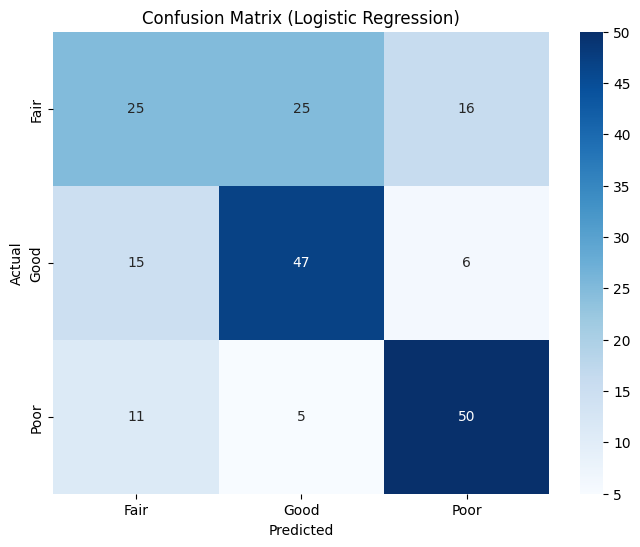

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred_lr = logistic_pipeline.predict(X_test)

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy (Logistic Regression): {accuracy_lr:.2f}")

print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=logistic_pipeline.classes_,
            yticklabels=logistic_pipeline.classes_)
plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature Importance Analysis: Logistic Regression

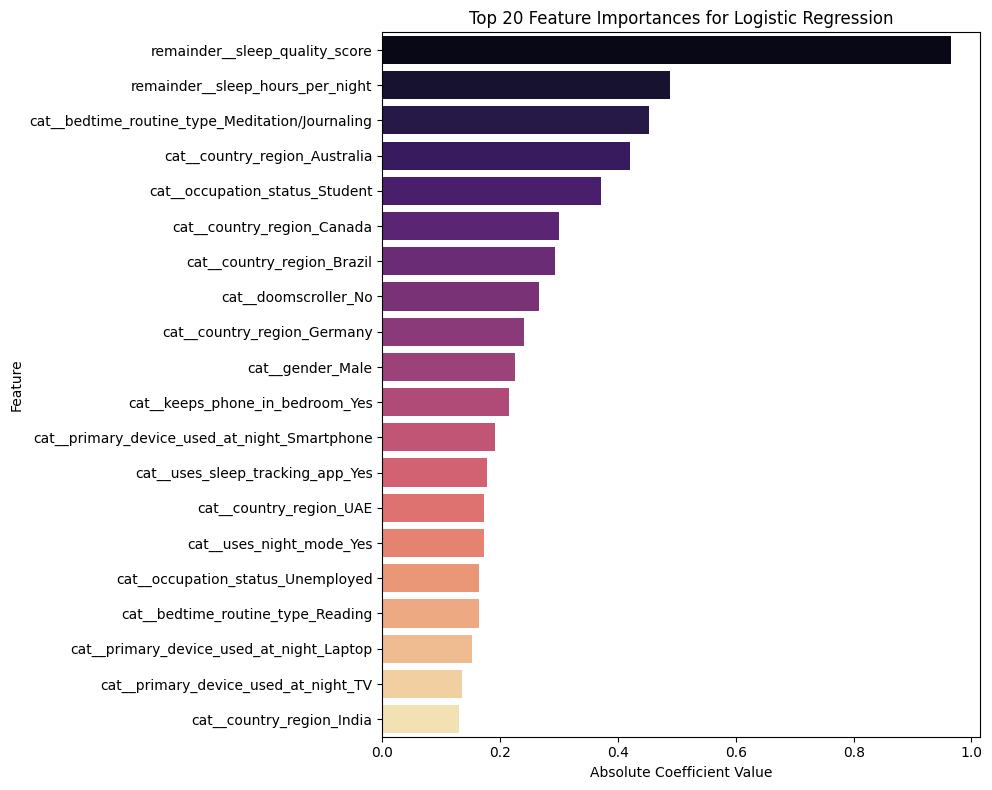

Top 20 Feature Importances for Logistic Regression:


,Feature,Importance
47,remainder__sleep_quality_score,0.965972
41,remainder__sleep_hours_per_night,0.488284
21,cat__bedtime_routine_type_Meditation/Journaling,0.452795
7,cat__country_region_Australia,0.420498
5,cat__occupation_status_Student,0.372051
9,cat__country_region_Canada,0.299187
8,cat__country_region_Brazil,0.293265
34,cat__doomscroller_No,0.265227
10,cat__country_region_Germany,0.240033
1,cat__gender_Male,0.225525


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get coefficients from the Logistic Regression model
logistic_coefficients = logistic_pipeline.named_steps['classifier'].coef_[0]

# Get feature names from the preprocessor
feature_names_lr = logistic_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Create a DataFrame for feature importances
importance_df_lr = pd.DataFrame({
    'Feature': feature_names_lr,
    'Importance': np.abs(logistic_coefficients) # Use absolute value for importance
})

# Sort by importance in descending order
importance_df_lr = importance_df_lr.sort_values(by='Importance', ascending=False)

# Plot the top 20 most important features for Logistic Regression
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_lr.head(20), palette='magma')
plt.title('Top 20 Feature Importances for Logistic Regression')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Top 20 Feature Importances for Logistic Regression:")
display(importance_df_lr.head(20))

### Comparison of Feature Importances

In [ ]:
print("\n--- Random Forest Top 10 Features ---")
display(importance_df.head(10))

print("\n--- Logistic Regression Top 10 Features ---")
display(importance_df_lr.head(10))

print("\nObservation: Both models highlight similar top features related to sleep hours, screen time, and doomscrolling behavior as important predictors of sleep quality. However, the order and specific emphasis on categorical features might differ slightly due to the inherent differences in how each model handles feature contributions (e.g., tree-based vs. linear coefficients).")


--- Random Forest Top 10 Features ---


,Feature,Importance
41,remainder__sleep_hours_per_night,0.062950
42,remainder__sleep_latency_minutes,0.059033
37,remainder__bedtime_screen_time_minutes,0.057759
53,remainder__weekly_sleep_debt_hours,0.057725
38,remainder__total_daily_screen_time_hours,0.048617
35,cat__doomscroller_Yes,0.045325
52,remainder__days_since_last_digital_detox,0.045258
44,remainder__caffeine_intake_mg_per_day,0.044095
40,remainder__avg_doomscroll_session_minutes,0.043935
51,remainder__exercise_minutes_per_day,0.043520



--- Logistic Regression Top 10 Features ---


,Feature,Importance
47,remainder__sleep_quality_score,0.965972
41,remainder__sleep_hours_per_night,0.488284
21,cat__bedtime_routine_type_Meditation/Journaling,0.452795
7,cat__country_region_Australia,0.420498
5,cat__occupation_status_Student,0.372051
9,cat__country_region_Canada,0.299187
8,cat__country_region_Brazil,0.293265
34,cat__doomscroller_No,0.265227
10,cat__country_region_Germany,0.240033
1,cat__gender_Male,0.225525



Observation: Both models highlight similar top features related to sleep hours, screen time, and doomscrolling behavior as important predictors of sleep quality. However, the order and specific emphasis on categorical features might differ slightly due to the inherent differences in how each model handles feature contributions (e.g., tree-based vs. linear coefficients).
